# Projeto Computacional de Mecânica Clássica

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from math import exp
from __future__ import annotations
from ipywidgets import FloatSlider, VBox, HBox, interactive_output
from IPython.display import display
from utils.linear_algebra import Vec3, sum_vec3

## Conceito de uma particula

In [76]:
class Particle:
    mass:float
    position: Vec3
    velocity: Vec3
    def __init__(self, mass: float, position: Vec3, velocity: Vec3) -> None:
        self.mass = mass
        self.position = position
        self.velocity = velocity
    def __repr__(self) -> str:
        return f"Particle(mass={self.mass}, position={self.position}, velocity={self.velocity})"
    
    def update_position(self, dt: float) -> None:
        self.position += self.velocity * dt
    def update_velocity(self, forces: list[Vec3], dt: float) -> None:
        total_force = sum_vec3(forces)
        acceleration = total_force / self.mass
        self.velocity += acceleration * dt

## Forças

### Força da gravidade 
#### $$\vec F_g = ma_g\cdot\hat k$$

In [77]:
def gravitational_force(particle: Particle, a:float) -> Vec3:
    magnitude = -particle.mass * a
    return Vec3(0, 0, magnitude)

### Força de arrasto
#### $$\begin{matrix}\beta_\uparrow(z) = \beta_0 e^{-z/ H} && \gamma_\uparrow(z) = \gamma_0 e^{-z/ H}\\\beta_\downarrow(z) = r_\beta\beta_\uparrow(z) && \gamma_\downarrow(z) = r_\gamma\gamma_\uparrow(z)\end{matrix}$$
#### $$\vec F_d =\begin{cases}- \beta_\uparrow(z)\vec v - \gamma_\uparrow(z)\|\vec v\|\vec v, & v_z > 0 \\- \beta_\downarrow(z)\vec v - \gamma_\downarrow(z)\|\vec v\|\vec v, & v_z < 0\end{cases}$$

In [78]:
def drag_beta_up(particle: Particle, beta_o: float, h: float) -> float:
    return beta_o * exp(-particle.position.z / h)
def drag_gamma_up(particle: Particle, gamma_o: float, h: float) -> float:
    return gamma_o * exp(-particle.position.z / h)
def drag_force(particle: Particle, beta_o: float, gamma_o: float, r_beta: float, r_gamma: float, h:float) -> Vec3:
    speed = particle.velocity.length()

    if particle.velocity.z > 0:
        beta = drag_beta_up(particle, beta_o, h)
        gamma = drag_gamma_up(particle, gamma_o, h)
    else:
        beta = r_beta * drag_beta_up(particle, beta_o, h)
        gamma = r_gamma * drag_gamma_up(particle, gamma_o, h)

    # SEMPRE oposto à velocidade
    return particle.velocity * (-beta - gamma*speed)

## Simulação

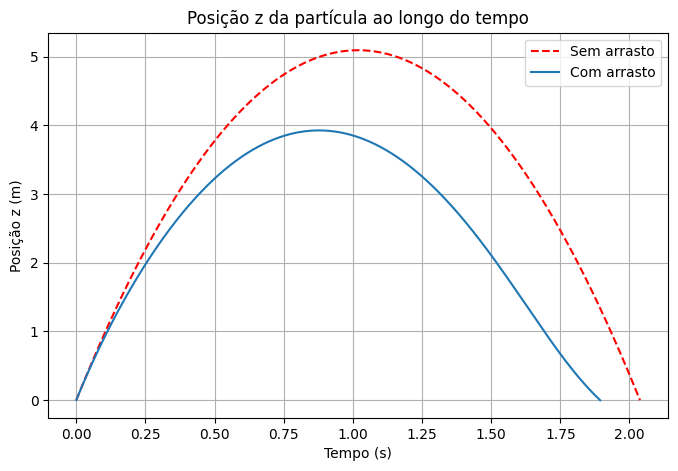

((np.float64(3.9242941684764543),
  np.float64(0.8770000000000007),
  np.float64(1.0169999999999015)),
 3.813748036373728,
 (np.float64(5.091841100000059),
  np.float64(1.0189999999999986),
  np.float64(1.018999999999888)),
 9.992779999999813)

In [79]:
## Parâmetros de simulação
TIME_STEP = 0.001                   # [s]
## Força Gravitacional
GRAVITATIONAL_ACCELERATION = 9.81   # [m/s^2]
## Força de arrasto
BETA_O = 1                          # [kg/s]
GAMMA_O = 0.05                      # [kg/m]
R_BETA = 5.0                        # [adimensional]
R_GAMMA = 5.0                       # [adimensional]
H = 10**0                           # [m]

def simulate_until_ground(
    velocity: Vec3 | None = None,
    a_g: float = GRAVITATIONAL_ACCELERATION, 
    beta_o: float = BETA_O, 
    gamma_o: float = GAMMA_O, 
    r_beta: float = R_BETA, 
    r_gamma: float = R_GAMMA, 
    h: float = H, 
    with_drag: bool = True
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64], Vec3]:
    if velocity is None:
        velocity = Vec3(0.0, 0.0, 10.0)
    
    particle = Particle(mass=1.0, position=Vec3(0.0, 0.0, 0.0), velocity=velocity)
    z_positions = [particle.position.z]
    times = [0.0]
    t = 0.0
    while particle.position.z >= 0:
        if with_drag:
            forces = [
                gravitational_force(particle, a=a_g),
                drag_force(particle, beta_o=beta_o, gamma_o=gamma_o, r_beta=r_beta, r_gamma=r_gamma, h=h)
            ]
        else:
            forces = [
                gravitational_force(particle, a=a_g)
            ]
        particle.update_velocity(forces, TIME_STEP)
        particle.update_position(TIME_STEP)
        t += TIME_STEP
        z_positions.append(particle.position.z)
        times.append(t)
        if len(times) > 1000/TIME_STEP:  # safety break for infinite loop
            break

    times_np = np.array(times)
    z_positions_np = np.array(z_positions)
    final_velocity = particle.velocity
    return times_np, z_positions_np, final_velocity
def extract_metrics(times: np.ndarray, z: np.ndarray):
    # altura máxima
    x_star = np.max(z)
    # índice do topo
    i_top = np.argmax(z)
    # tempo de subida
    tau_up = times[i_top]
    # tempo total
    t_total = times[-1]
    # tempo de descida
    tau_down = t_total - tau_up

    return x_star, tau_up, tau_down

times_drag, z_drag, v_drag = simulate_until_ground()
times_no_drag, z_no_drag, v_no_drag = simulate_until_ground(with_drag=False)

plt.figure(figsize=(8,5))
plt.plot(times_no_drag, z_no_drag, 'r--', label='Sem arrasto')
plt.plot(times_drag, z_drag, label='Com arrasto')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição z (m)')
plt.title('Posição z da partícula ao longo do tempo')
plt.legend()
plt.grid(True)
plt.show()

extract_metrics(times_drag, z_drag), v_drag.length(), extract_metrics(times_no_drag, z_no_drag), v_no_drag.length()

## Simulação Interativa
Ajuste os parâmetros abaixo para ver como afetam a trajetória da partícula em tempo real.

In [ ]:
# Criar sliders para os parâmetros
beta_o_slider = FloatSlider(value=BETA_O, min=0.1, max=5.0, step=0.1, description='β₀ (kg/s):', continuous_update=True)
gamma_o_slider = FloatSlider(value=GAMMA_O, min=0.01, max=0.5, step=0.01, description='γ₀ (kg/m):', continuous_update=True)
r_beta_slider = FloatSlider(value=R_BETA, min=1.0, max=20.0, step=0.5, description='rβ:', continuous_update=True)
r_gamma_slider = FloatSlider(value=R_GAMMA, min=1.0, max=20.0, step=0.5, description='rγ:', continuous_update=True)
h_slider = FloatSlider(value=H, min=0.1, max=5.0, step=0.1, description='H (m):', continuous_update=True)
v_z_slider = FloatSlider(value=10.0, min=1.0, max=50.0, step=1.0, description='v_z inicial (m/s):', continuous_update=True)

def plot_simulation(beta_o, gamma_o, r_beta, r_gamma, h, v_z):
    """Função para atualizar o gráfico com os parâmetros selecionados"""
    times_drag, z_drag, v_star = simulate_until_ground(
        velocity=Vec3(0.0, 0.0, v_z),
        beta_o=beta_o,
        gamma_o=gamma_o,
        r_beta=r_beta,
        r_gamma=r_gamma,
        h=h,
    )
    
    times_no_drag, z_no_drag, v_no_drag = simulate_until_ground(
        velocity=Vec3(0.0, 0.0, v_z),
        with_drag=False
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(times_no_drag, z_no_drag, 'r--', linewidth=2, label='Sem arrasto', alpha=0.7)
    plt.plot(times_drag, z_drag, 'b-', linewidth=2, label='Com arrasto')
    plt.xlabel('Tempo (s)', fontsize=12)
    plt.ylabel('Posição z (m)', fontsize=12)
    plt.title('Simulação de Partícula em Queda Livre com Arrasto', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Exibir métricas
    x_star, tau_up, tau_down = extract_metrics(times_drag, z_drag)
    print(f"Com arrasto:")
    print(f"  Altura máxima: {x_star:.3f} m")
    print(f"  Velocidade final: {v_star.length():.3f} m/s")
    print(f"  Tempo de subida: {tau_up:.3f} s")
    print(f"  Tempo de descida: {tau_down:.3f} s")

# Criar a interface interativa
output = interactive_output(
    plot_simulation,
    {
        'beta_o': beta_o_slider,
        'gamma_o': gamma_o_slider,
        'r_beta': r_beta_slider,
        'r_gamma': r_gamma_slider,
        'h': h_slider,
        'v_z': v_z_slider
    }
)

# Organizar os sliders em um layout
sliders_box = VBox([
    HBox([beta_o_slider, gamma_o_slider]),
    HBox([r_beta_slider, r_gamma_slider]),
    HBox([h_slider, v_z_slider])
])

# Exibir a interface
display(sliders_box, output)

Output()